# 04 — Modelling & Evaluation

This notebook drives the production training script (`src.train.main`) end-to-end and displays the resulting artefacts: cross-validation comparison, threshold tuning, held-out test metrics, ROC/PR curves and SHAP explanations.

**Strategy**
* stratified 60/20/20 train/validation/test split;
* 5-fold stratified cross-validation of Logistic Regression, Random Forest and XGBoost;
* class imbalance handled with class weights / `scale_pos_weight` (no SMOTE — see README);
* decision threshold tuned on the validation set (F1);
* final evaluation on the untouched test set.

In [1]:
import sys
sys.path.insert(0, 'C:\\Users\\OUISSAL\\Production-Ready Customer Churn')  # make 'src' importable
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

import pandas as pd
from src import config
from src.train import main

# cleaning -> feature engineering -> CV -> selection ->
# threshold tuning -> final training -> evaluation -> SHAP
metrics = main()

 CUSTOMER CHURN PREDICTION — TRAINING PIPELINE

[1/7] Loading and cleaning data ...
       7043 rows loaded, 22 feature columns after engineering, churn rate 26.5%


[2/7] Stratified split: train=4225  validation=1409  test=1409
       scale_pos_weight (XGBoost) = 2.77
[3/7] 5-fold stratified cross-validation (random_state=42) ...


       Logistic Regression  ROC-AUC=0.8485 ±0.0126 | F1=0.6301 | Recall=0.8011


       Random Forest        ROC-AUC=0.8404 ±0.0121 | F1=0.6276 | Recall=0.7101


       XGBoost              ROC-AUC=0.8381 ±0.0101 | F1=0.6265 | Recall=0.7413

       Selected model: Logistic Regression
[4/7] Tuning decision threshold on the validation set (maximising f1) ...


       Best threshold = 0.61 -> precision=0.573, recall=0.706, f1=0.632
[5/7] Refitting the selected model on train + validation ...
[6/7] Evaluating on the held-out test set ...


       @ threshold 0.50   : acc=0.7331 | prec=0.4983 | recall=0.7914 | f1=0.6116 | auc=0.8420
       @ tuned threshold  : acc=0.7757 | prec=0.5620 | recall=0.7032 | f1=0.6247 | auc=0.8420
[7/7] Generating figures and persisting artefacts ...



Saved model   : C:\Users\OUISSAL\Production-Ready Customer Churn\models\churn_model.joblib
Saved metrics : C:\Users\OUISSAL\Production-Ready Customer Churn\models\metrics.json
Saved figures : C:\Users\OUISSAL\Production-Ready Customer Churn\reports\figures

Training completed successfully.


## 1. Cross-validation comparison (5-fold, stratified)

In [2]:
pd.DataFrame(metrics['cv_table']).round(4)

,model,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std
0,Logistic Regression,0.8485,0.0126,0.6301,0.0134,0.8011,0.0110,0.5194,0.0151
1,Random Forest,0.8404,0.0121,0.6276,0.0165,0.7101,0.0250,0.5628,0.0203
2,XGBoost,0.8381,0.0101,0.6265,0.0099,0.7413,0.0242,0.5432,0.0167


## 2. Model selection & decision threshold

In [3]:
print('Selected model :', metrics['model_name'])
print('Selection rule :', metrics['selection_rule'])
print('Best threshold :', metrics['threshold'],
      f"(maximising {metrics['threshold_metric']})")
print('Validation metrics at tuned threshold:',
      {k: round(v, 3) for k, v in
       metrics['validation_metrics_at_tuned_threshold'].items()})

Selected model : Logistic Regression
Selection rule : ROC-AUC first; F1 (churn) tie-break within 0.005; interpretability as final tie-break
Best threshold : 0.61 (maximising f1)
Validation metrics at tuned threshold: {'threshold': 0.61, 'precision': 0.573, 'recall': 0.706, 'f1': 0.632}


## 3. Test-set evaluation (held out, never used during training)

In [4]:
results = pd.DataFrame([
    {'scenario': 'threshold = 0.50',
     **metrics['test_metrics_threshold_050']},
    {'scenario': f"tuned threshold = {metrics['threshold']}",
     **metrics['test_metrics_tuned_threshold']},
])
cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
results.set_index('scenario')[cols].round(4)

,accuracy,precision,recall,f1,roc_auc
scenario,,,,,
threshold = 0.50,0.7331,0.4983,0.7914,0.6116,0.842
tuned threshold = 0.61,0.7757,0.5620,0.7032,0.6247,0.842


## 4. Diagnostic figures

confusion_matrix_test.png


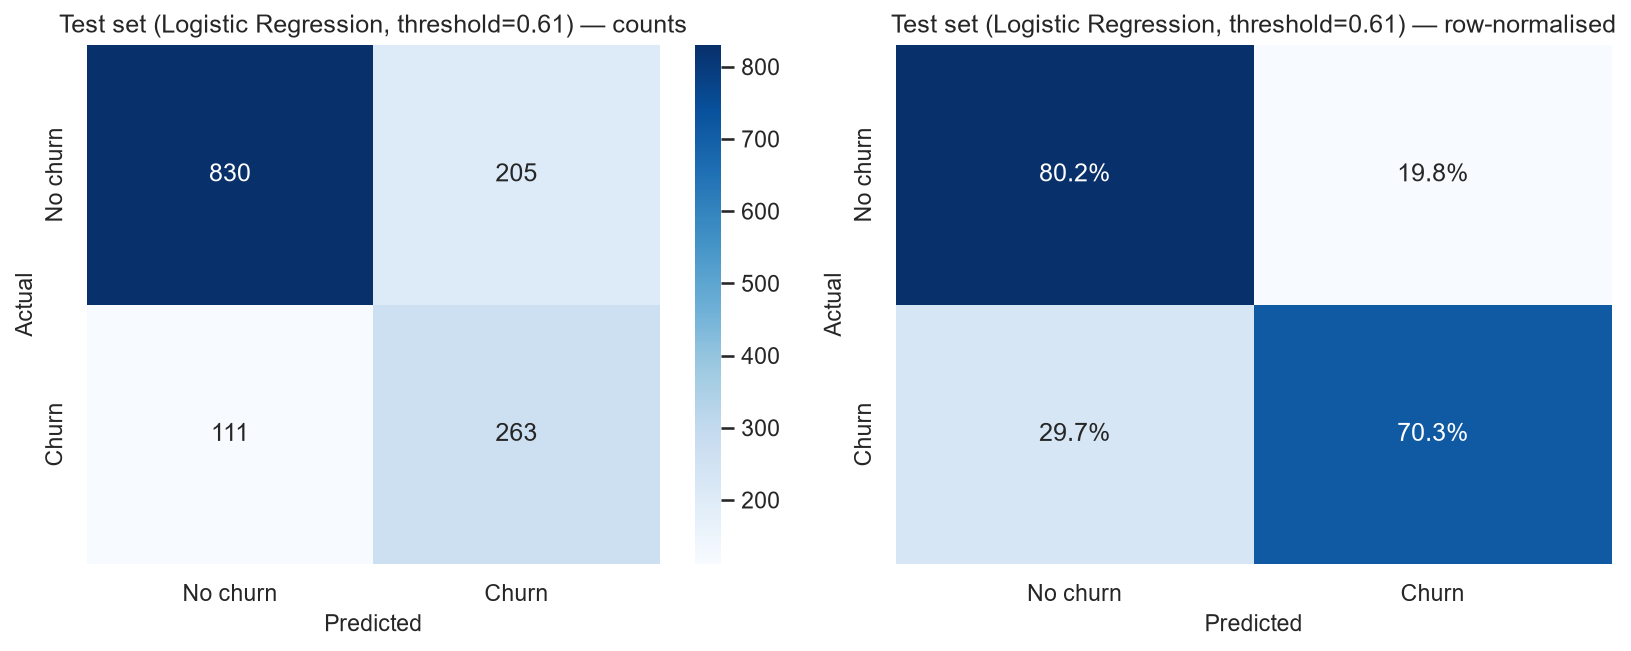

roc_curves.png


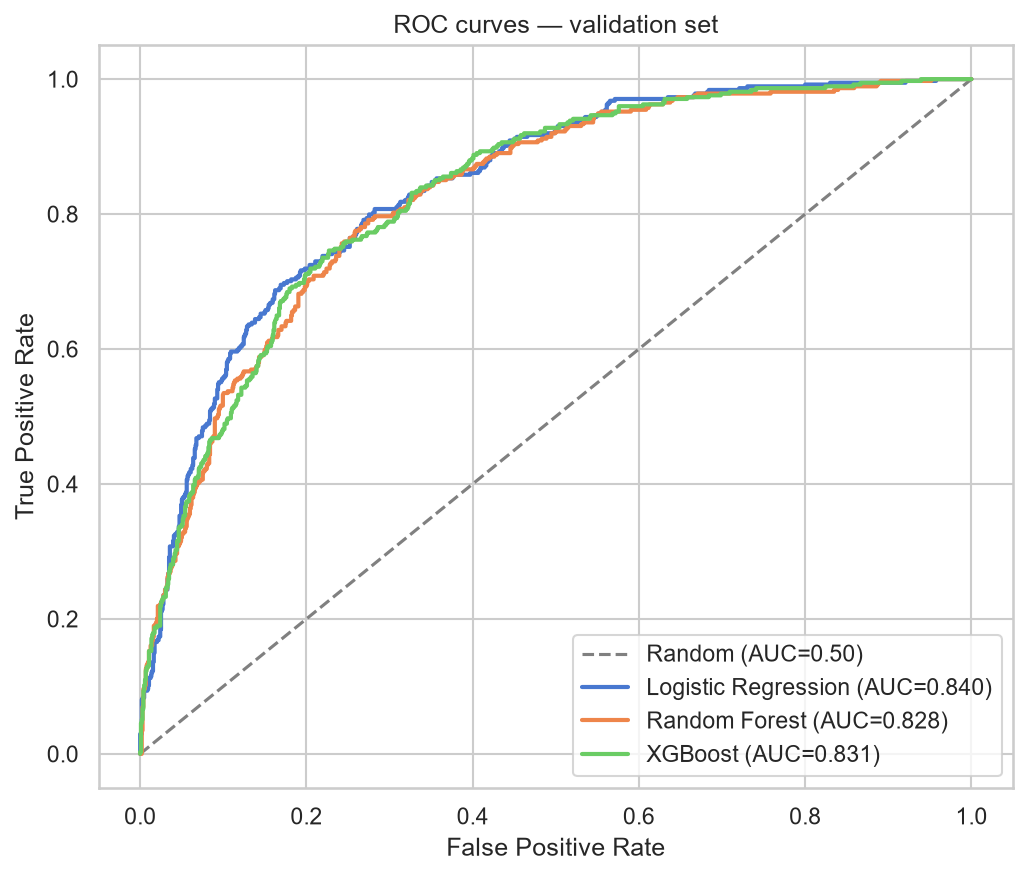

pr_curve.png


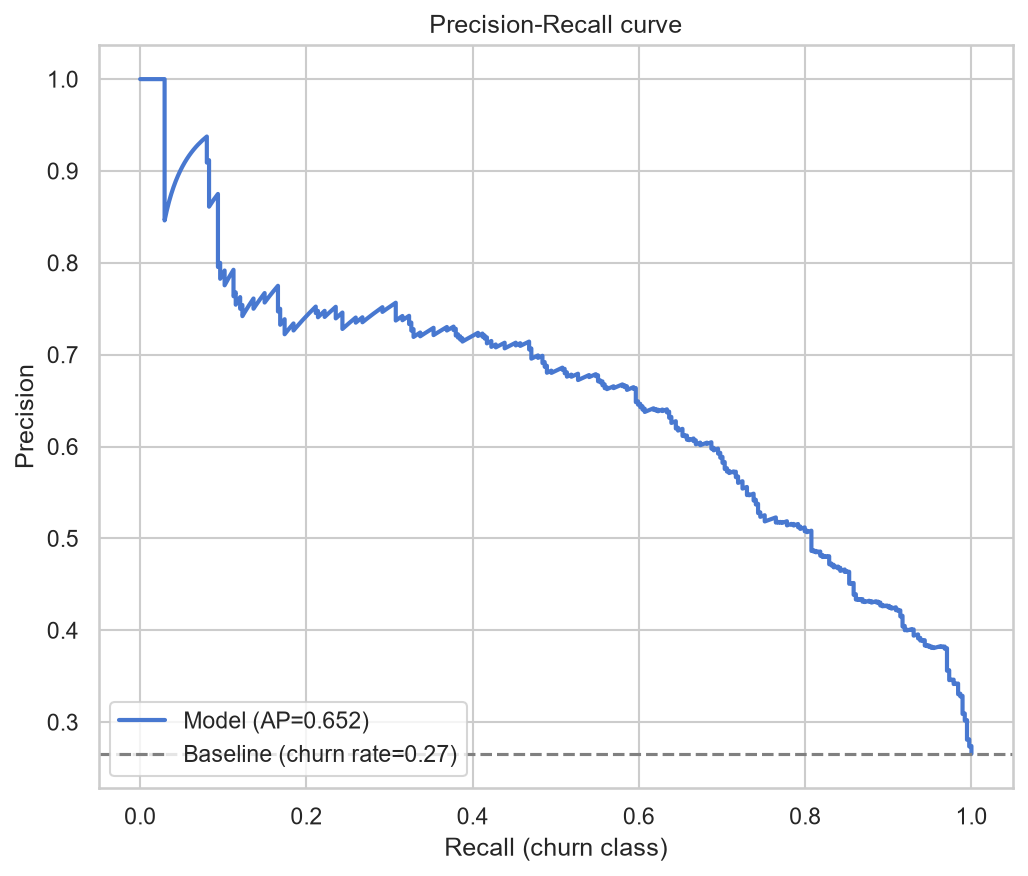

threshold_curve.png


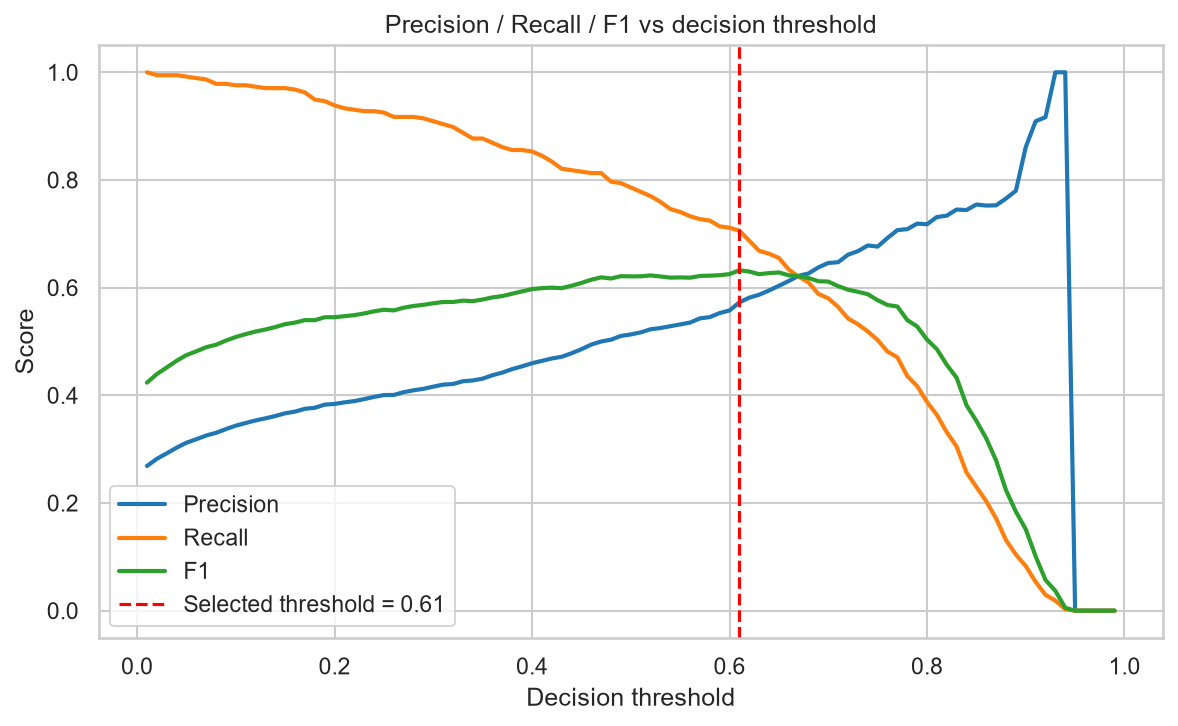

In [5]:
from IPython.display import Image, display

for name in ['confusion_matrix_test.png', 'roc_curves.png',
             'pr_curve.png', 'threshold_curve.png']:
    print(name)
    display(Image(str(config.FIGURES_DIR / name)))

## 5. SHAP — global explanations

shap_importance.png


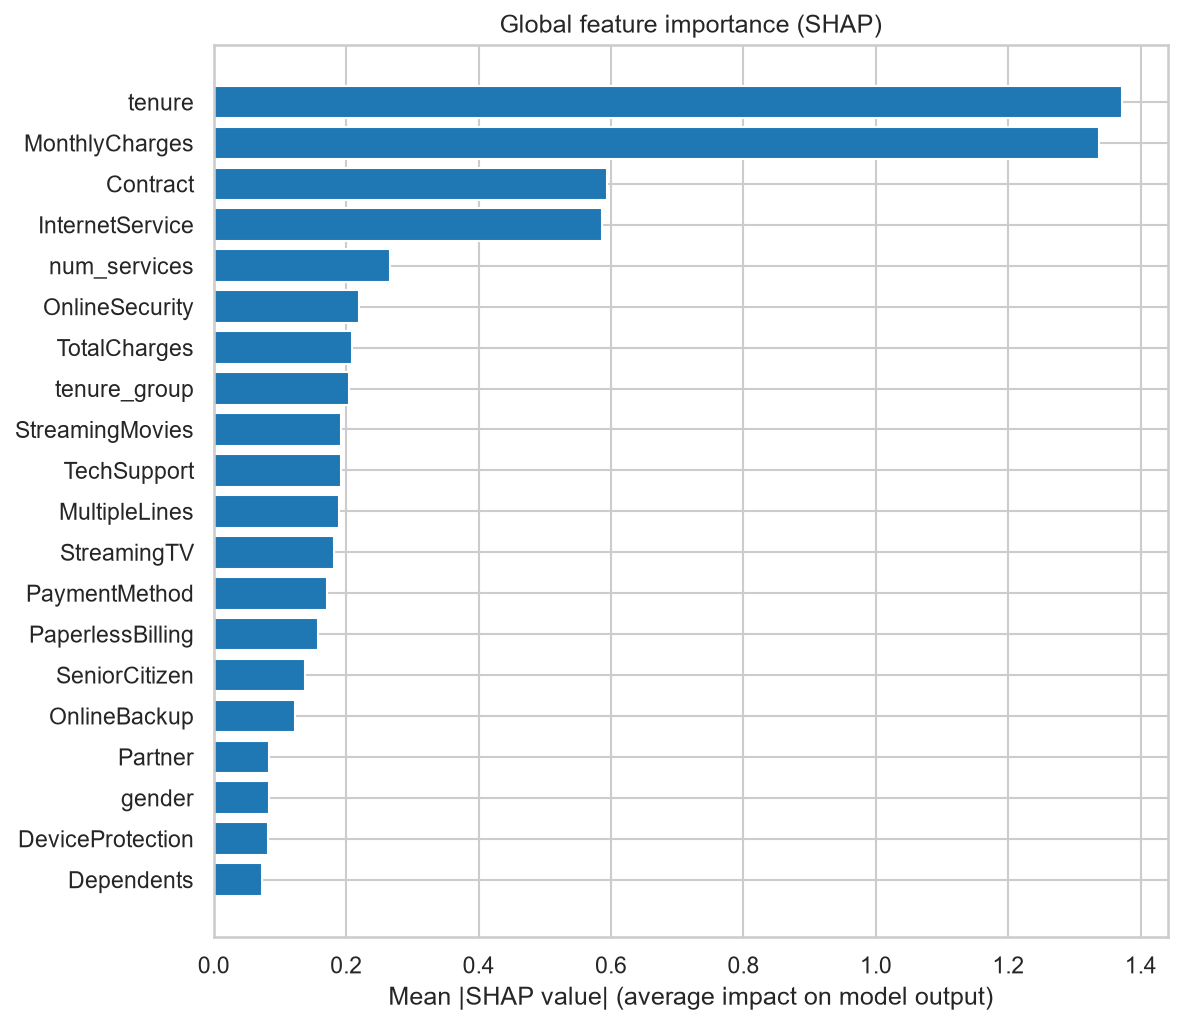

shap_summary.png


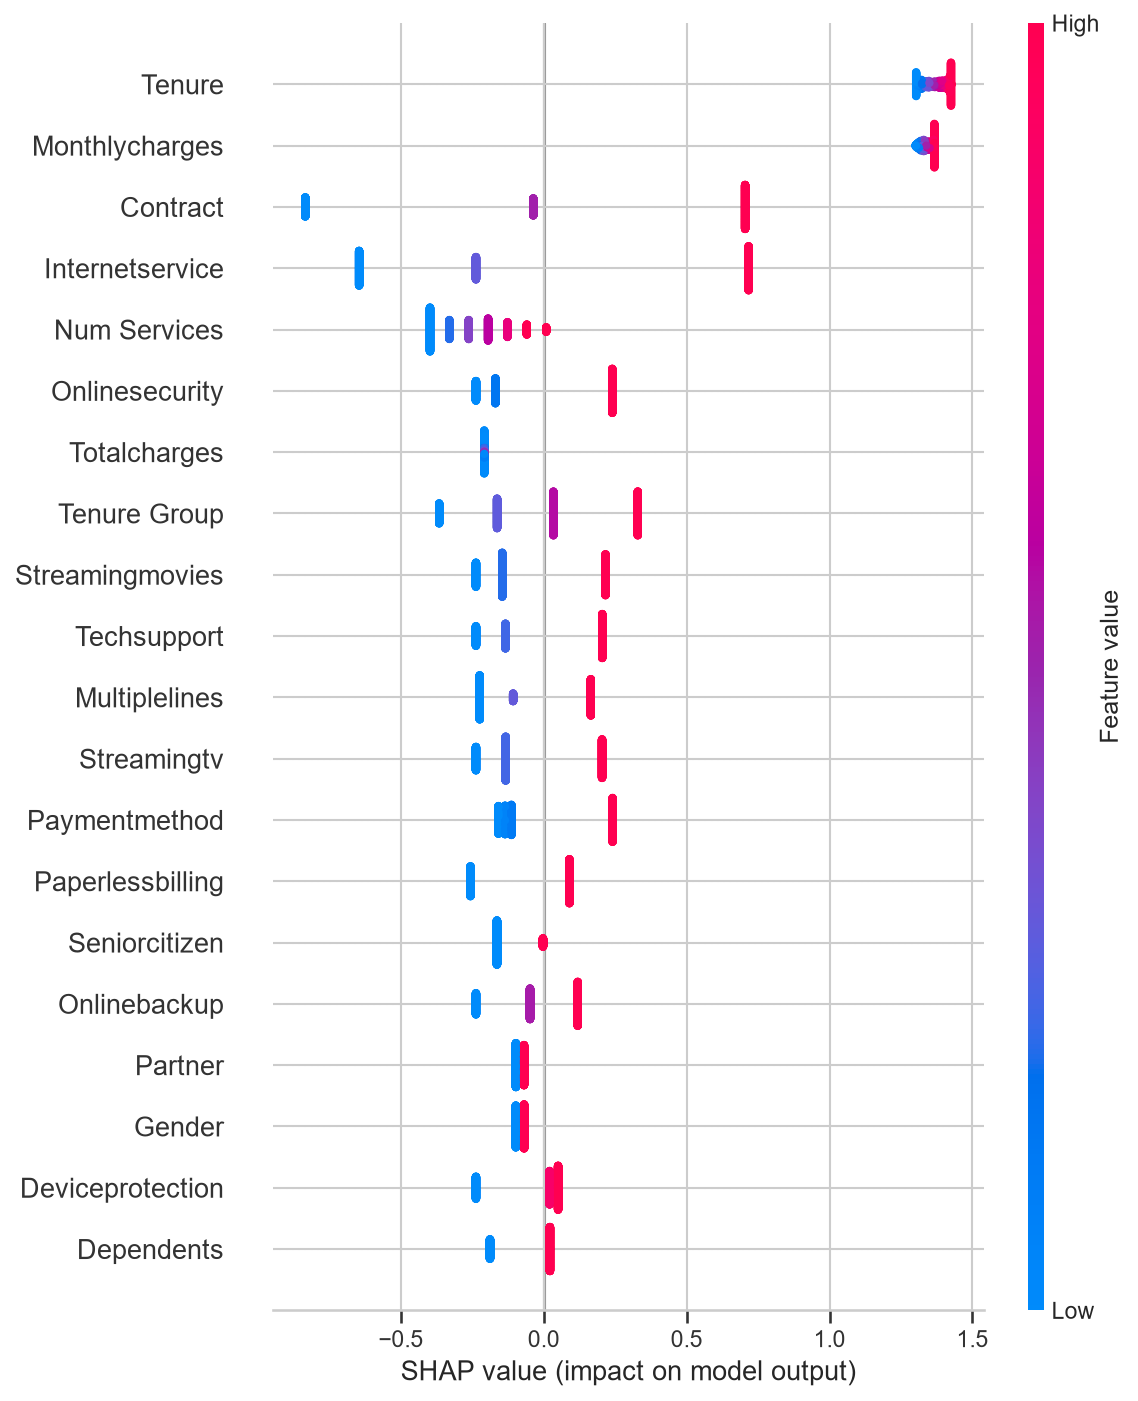

In [6]:
for name in ['shap_importance.png', 'shap_summary.png']:
    print(name)
    display(Image(str(config.FIGURES_DIR / name)))

## 6. Individual prediction & explanation

In [7]:
from src.predict import explain_prediction, predict_customer

customer = {
    'gender': 'Female', 'SeniorCitizen': 'No', 'Partner': 'No',
    'Dependents': 'No', 'tenure': 2, 'PhoneService': 'Yes',
    'MultipleLines': 'No', 'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No', 'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No',
    'StreamingTV': 'Yes', 'StreamingMovies': 'No',
    'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 95.2, 'TotalCharges': 190.4,
}
result = predict_customer(customer)
print(f"Prediction: {result['prediction']}")
print(f"Churn probability: {result['churn_probability']:.1%}")
print(f"Confidence: {result['confidence']:.1%}")

explanation = explain_prediction(customer)
print('Top drivers:')
for _, row in explanation['table'].head(8).iterrows():
    print(f"  {row['feature']:>18} = {str(row['value']):<24} "
          f"-> {row['direction']} risk")

Prediction: HIGH CHURN RISK
Churn probability: 86.5%
Confidence: 86.5%
Top drivers:
              tenure = 2                        -> increases risk
      MonthlyCharges = 95.2                     -> increases risk
     InternetService = Fiber optic              -> increases risk
            Contract = Month-to-month           -> increases risk
        num_services = 1                        -> decreases risk
       PaymentMethod = Electronic check         -> increases risk
      OnlineSecurity = No                       -> increases risk
       MultipleLines = No                       -> decreases risk


## Conclusion

* All three models clearly beat a majority-class baseline; the comparison table above reports the actual cross-validation scores.
* The selected model balances ROC-AUC, churn recall and interpretability (see the selection rule).
* The tuned threshold improves the precision/recall trade-off for a retention campaign.
* The saved pipeline in `models/` powers `src/predict.py` and the Streamlit application.